# Model 3: mDeBERTa-V3

---

**Python Version: 3.10.12**

**CUDA Version: 13.1**

**PyTorch Version: 2.5.1+cu121**

---

### AI Tool Usage Declaration

 GitHub Copilot Autocomplete was used to autocomplete and fill in many of the comments seen throughout my code as well as autocomplete some redundent code elements that were already present in the code and just needed to be written again. Since GitHub Copilot is able to simply suggest these code elements, they were simply accepted instead of having to manually be rewritten. Since data is not available regarding the carbon emissions of GitHub Copilot autocomplete, we will be treating each autocomplete as a ChatGPT querry as GitHub Copilot is powered by ChatGPT. Therefore, using the provided metric of 4.32g of carbon emissions for a ChatGPT querry, the total carbon emission for using GitHub Copilot autocomplete for comments and writing redudent code is calculated at 4.32g x 1 = 4.32g.

---

## 0. Installation and Packages

In [27]:
# Install required packages (uncomment as needed)
# !pip install transformers datasets scikit-learn torch evaluate accelerate
# !pip install sentencepiece  # needed for some tokenizers
# !pip install -U adapters datasets evaluate accelerate
# !pip install tensorboard
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Core imports
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

# HuggingFace
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
import evaluate

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Other
from pathlib import Path
import csv
import random
import matplotlib.pyplot as plt

import adapters
from adapters import LoRAConfig

import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# CUDA check

USECUDA = torch.cuda.is_available()
DEVICE = "cuda" if USECUDA else "cpu"

print(f"Using device: {DEVICE}")
if USECUDA:
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")


Using device: cuda
Using GPU: NVIDIA GeForce RTX 3060 Ti


## 1. Initialization and Setup

### 1.1. Languages

In [3]:
languages = ['af', 'de', 'en', 'es', 'fr', 'id', 'it', 'nl', 'pt', 'sv', 'tl', 'tr']

### 1.2. Loading the Dataset

#### 1.2.1. Read CSV Function

In [4]:
def read_csv_safe(path, has_lang=True):
    dataset = []
    with open(path, 'r', encoding='utf-8') as f:
        header = f.readline()  # skip header
        for line in f:
            line = line.strip()
            if not line:
                continue
            if has_lang:
                # Split on the LAST comma to capture lang correctly
                try:
                    id_text, lang = line.rsplit(',', 1)
                    id_val, text = id_text.split(',', 1)
                    dataset.append({'id': id_val, 'text': text, 'lang': lang})
                except ValueError:
                    print(f"Skipping malformed line in {path}: {line}")
            else:
                try:
                    id_val, text = line.split(',', 1)
                    dataset.append({'id': id_val, 'text': text})
                except ValueError:
                    print(f"Skipping malformed line in {path}: {line}")
    return dataset

In [ ]:
train_dataset = []
val_dataset = []
test_dataset = []

# Load all datasets
train_dataset.extend(read_csv_safe(f"dataset/train.csv", has_lang=True))
val_dataset.extend(read_csv_safe(f"dataset/validation.csv", has_lang=True))
test_dataset.extend(read_csv_safe(f"dataset/test.csv", has_lang=False))


### 1.3. Dataset Exploration

#### 1.3.1. Training Data Visualization

In [6]:
# Visualize the training dataset
print("Sample training data:")
train_df = pd.DataFrame(train_dataset)
train_df.head(10)

Sample training data:


,id,text,lang
0,0,ci sono lavori in corso sulla a quattordici,it
1,1,schlummer alle heutigen wecker permanent,de
2,2,gibt es irgendwelche status updates von tagess...,de
3,3,hur många kalorier är det i en apelsin,sv
4,4,sei stumm,de
5,5,eliminar todas mis citas de hoy,es
6,6,peux-tu créer une nouvelle liste dans la liste...,fr
7,7,tell me the news in technology from engadget,en
8,8,invia una email di avviso a sonia,it
9,9,tolong cek alarm lainnya yang ada setelah jam ...,id


#### 1.3.2. Validation Data Visualization

In [7]:
# Visualize the validation dataset
print("Sample validation data:")
val_df = pd.DataFrame(val_dataset)
val_df.head(10)

Sample validation data:


,id,text,lang
0,0,achas que viajar no tempo é possível,pt
1,1,magpadala ng email kay nanay na ang topiko sa ...,tl
2,2,nakatakda ba ang pagpupulong bukas,tl
3,3,toon ons rood,nl
4,4,definiera månen för mig,sv
5,5,wat weet jy van die standbeeld van vryheid,af
6,6,her gün sabah dokuzda bir hatırlatmaya ihtiyac...,tr
7,7,tweet verbruiker diens nie goed per liter per ...,af
8,8,che eventi ho nel calendario,it
9,9,check meinen posteingang,de


#### 1.3.3. Test Data Visualization

In [8]:
# Visualize the test dataset
print("Sample test data:")
test_df = pd.DataFrame(test_dataset)
test_df.head(10)

Sample test data:


,id,text
0,0,google ställ in påminnelse
1,1,tekrar alacakaranlık kuşağı nın sesli pleybeki...
2,2,scrivi una email ad anna ciao come stai oggi
3,3,bitte prüfe meine emails und sag bescheid ob i...
4,4,remover reunião da próxima segunda feira
5,5,set a reminder for the thirteenth that i have ...
6,6,lees me nieuwe post voor op mijn feed
7,7,open alsjeblieft het schaak spel ik zou graag ...
8,8,ano ang nilagay ko sa listahan ng puregold
9,9,démarre plus belle la vie


## 2. Model

### 2.1. Model Initialization

In [9]:
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification

MODEL_NAME = "microsoft/mdeberta-v3-base"

tokenizer = DebertaV2Tokenizer.from_pretrained(MODEL_NAME) 
model = DebertaV2ForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(languages))

model.to(DEVICE)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/mdeberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(251000, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): Layer

### 2.2. Tokenization and Encoding

In [10]:
# Tokenize the dataset for Model 1
def tokenize_function(examples: dict) -> dict:
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

In [11]:
# First preprocess all the data
# Using the code from the baseline
for split_df in [train_df, val_df, test_df]:
    split_df["text"] = split_df["text"].fillna("")

# Load the data

# Train
X_train_text = train_df["text"]
y_train = train_df["lang"]

# Validation
X_val_text = val_df["text"]
y_val = val_df["lang"]

# Test
X_test_text = test_df["text"]

# Tokenize each split correctly
train_dataset = Dataset.from_pandas(pd.DataFrame([
    {**tokenize_function({"text": text}), "labels": languages.index(label)}
    for text, label in zip(X_train_text, y_train)
]))

val_dataset = Dataset.from_pandas(pd.DataFrame([
    {**tokenize_function({"text": text}), "labels": languages.index(label)}
    for text, label in zip(X_val_text, y_val)
]))

test_dataset = Dataset.from_pandas(pd.DataFrame([
    tokenize_function({"text": text})
    for text in X_test_text
]))

#### 2.2.1. Train Dataset Distribution

Train set class counts:
af    5000
de    5000
en    5000
es    5000
fr    5000
id    5000
it    5000
nl    5000
pt    5000
sv    5000
tl    5000
tr    5000
Name: count, dtype: int64


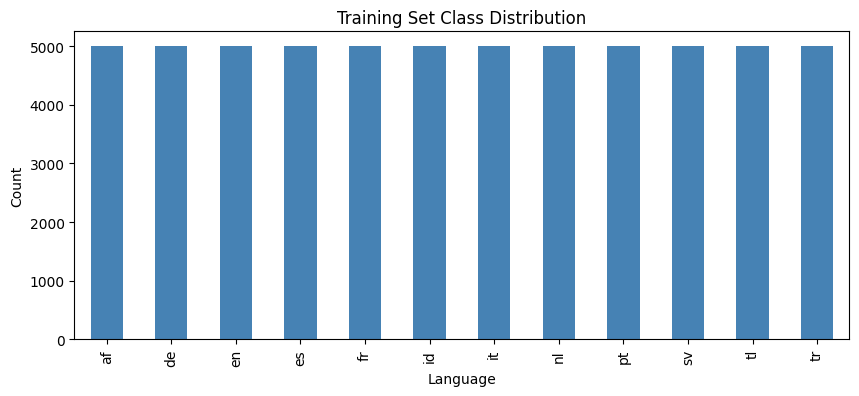

In [12]:
train_labels_series = pd.Series(train_dataset["labels"])
train_label_counts = train_labels_series.map(lambda i: languages[i]).value_counts().reindex(languages, fill_value=0)

print("Train set class counts:")
print(train_label_counts)

train_label_counts.plot(
    kind="bar",
    figsize=(10, 4),
    color="steelblue",
    title="Training Set Class Distribution"
)
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

#### 2.2.2. Validation Dataset Distribution

Validation set class counts:
af    2033
de    2033
en    2033
es    2033
fr    2033
id    2033
it    2033
nl    2033
pt    2033
sv    2033
tl    2033
tr    2033
Name: count, dtype: int64


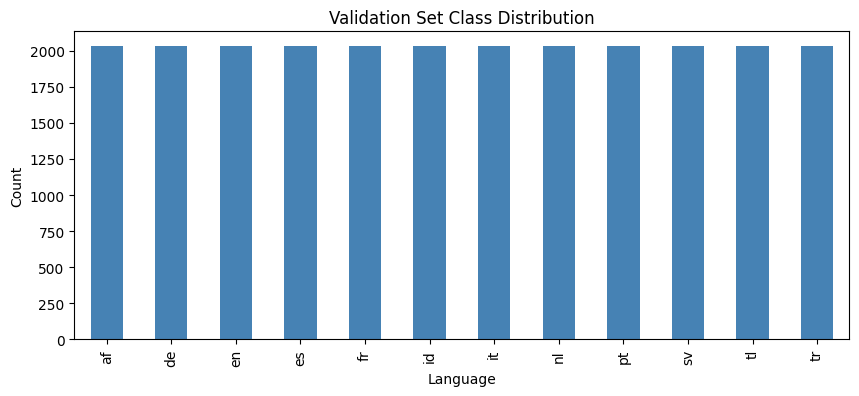

In [13]:
val_labels_series = pd.Series(val_dataset["labels"])
val_label_counts = val_labels_series.map(lambda i: languages[i]).value_counts().reindex(languages, fill_value=0)

print("Validation set class counts:")
print(val_label_counts)

val_label_counts.plot(
    kind="bar",
    figsize=(10, 4),
    color="steelblue",
    title="Validation Set Class Distribution"
)
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

### 2.3. Model Training

#### 2.3.1. Hyperparameters

In [14]:
output_dir = "./results-model"
batch_size = 16
learning_rate = 2e-5
epochs = 3

#### 2.3.2 Adapter

In [15]:
adapters.init(model)

config = LoRAConfig(
    r=8,         # Low-rank dimension
    alpha=16,    # Scaling factor
    dropout=0.0  # (Optional) dropout in LoRA layers
)

model.add_adapter("lora_adapter", config=config)
model.set_active_adapters("lora_adapter")
model.train_adapter("lora_adapter")

There are adapters available but none are activated for the forward pass.


#### 2.3.3. Training Loop

In [16]:
training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=learning_rate,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    logging_steps=10,
    num_train_epochs=epochs,
    weight_decay=0.001,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=3,
    fp16=USECUDA,
    use_cpu=not USECUDA,
    dataloader_pin_memory=USECUDA
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda p: {
        "accuracy": accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1)),
        "f1": f1_score(p.label_ids, np.argmax(p.predictions, axis=1), average="weighted"),
    },
)

out_path = Path(output_dir)
checkpoints = sorted(
    [p for p in out_path.glob("checkpoint-*") if p.is_dir()],
    key=lambda p: int(p.name.split("-")[-1]),
)

if checkpoints:
    latest_ckpt = str(checkpoints[-1])
    print(f"Found checkpoint: {latest_ckpt} -> resuming training")
    trainer.train(resume_from_checkpoint=latest_ckpt)
elif (out_path / "model.safetensors").exists() or (out_path / "pytorch_model.bin").exists():
    print(f"Found saved model in {output_dir} -> loading existing model (no retraining)")
    model = DebertaV2ForSequenceClassification.from_pretrained(output_dir)
    model.to(DEVICE)
    trainer.model = model
else:
    print("No existing model/checkpoint found -> training from scratch")
    trainer.train()


Found checkpoint: results-model/checkpoint-11250 -> resuming training


There were missing keys in the checkpoint model loaded: ['deberta.prompt_tuning.base_model_embeddings.weight'].
There were missing keys in the checkpoint model loaded: ['deberta.prompt_tuning.base_model_embeddings.weight'].


Epoch,Training Loss,Validation Loss


### 2.4. Validation Results

In [20]:
# Predict labels on the validation split
val_pred_output = trainer.predict(val_dataset)
val_pred_ids = np.argmax(val_pred_output.predictions, axis=1)

# Convert numeric predictions back to string labels
val_pred_labels = [languages[pred_id] for pred_id in val_pred_ids]

accuracy = accuracy_score(y_val, val_pred_labels)
f1 = f1_score(y_val, val_pred_labels, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, val_pred_labels))

Accuracy: 0.9620
F1 Score: 0.9619

Classification Report:
              precision    recall  f1-score   support

          af       0.94      0.86      0.90      2033
          de       0.98      0.98      0.98      2033
          en       0.96      0.99      0.98      2033
          es       0.93      0.97      0.95      2033
          fr       0.98      0.99      0.99      2033
          id       0.98      0.98      0.98      2033
          it       0.98      0.97      0.97      2033
          nl       0.89      0.94      0.91      2033
          pt       0.97      0.94      0.95      2033
          sv       0.98      0.97      0.97      2033
          tl       0.97      0.97      0.97      2033
          tr       0.99      0.99      0.99      2033

    accuracy                           0.96     24396
   macro avg       0.96      0.96      0.96     24396
weighted avg       0.96      0.96      0.96     24396



### 2.5. Model Prediction

In [21]:
# Predict labels on the test split
test_pred_output = trainer.predict(test_dataset)
test_pred_ids = np.argmax(test_pred_output.predictions, axis=1)

# Convert numeric predictions back to string labels
test_pred_labels = [languages[pred_id] for pred_id in test_pred_ids]

# Build submission file in required format: id,label
submission_model = pd.DataFrame({
    "id": test_df["id"].astype(int),
    "lang": test_pred_labels
})

# Order the submission by id just in case
submission_model = submission_model.sort_values("id")

submission_model.to_csv("prediction_results.csv", index=False)

### 2.6. Sanity Check

In [22]:
# Our own test cases for sanity check.
validation = [
  'jangan pergi main di sana',
  'what is your name?',
  'escuela de idiomas',
  'je suis un étudiant',
  'eetsmakelijk', # Dutch for "enjoy your meal" -- Misclassified as Turkish in baseline.
  'buon appetito',
  'danke schön', # German for "thank you very much" -- Misclassified as Turkish in baseline.
]
x_val_sanity = Dataset.from_dict(
    tokenizer(validation, padding="max_length", truncation=True, max_length=128)
)

sanity_pred_output = trainer.predict(x_val_sanity)
sanity_pred_ids = np.argmax(sanity_pred_output.predictions, axis=1)
sanity_pred_labels = [languages[i] for i in sanity_pred_ids]

pd.DataFrame({"text": validation, "pred_lang": sanity_pred_labels})

,text,pred_lang
0,jangan pergi main di sana,id
1,what is your name?,en
2,escuela de idiomas,es
3,je suis un étudiant,fr
4,eetsmakelijk,af
5,buon appetito,it
6,danke schön,de


In [17]:
check = "gratis"
x_check = Dataset.from_dict(
    tokenizer([check], padding="max_length", truncation=True, max_length=128)
)

check_pred_output = trainer.predict(x_check)
check_pred_id = np.argmax(check_pred_output.predictions, axis=1)[0]
check_pred_label = languages[check_pred_id]

print(f"Input: '{check}' -> Predicted language: {check_pred_label}")

Input: 'gratis' -> Predicted language: es


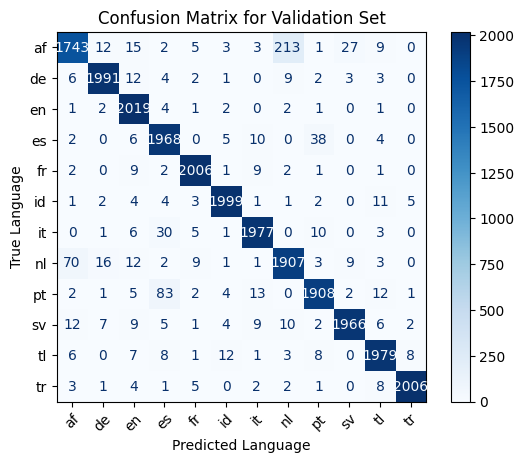

In [28]:
cm = confusion_matrix(y_val, val_pred_labels, labels=languages)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=languages)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Validation Set")
plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.show()